## Skin Cancer Classificator

Este proyecto implementa un clasificador binario de cáncer de piel (benigno vs. maligno) basado en redes neuronales convolutivas (CNN) con PyTorch. Las imágenes pertenecen a un dataset de imágenes de Kaggle, las guardamos en una carpeta accesible, se redimensionan a 224×224 píxeles y se normalizan. El conjunto se divide de forma reproducible (semilla fija) en entrenamiento (80%) y prueba (20%), y se itera con DataLoader para un procesamiento por lotes eficiente.

La arquitectura utilizada se basa en transfer learning empleando el modelo ResNet-18, preentrenado sobre el conjunto de datos ImageNet. Se reutilizan las capas convolucionales del modelo como extractor de características y se reemplaza la capa totalmente conectada final por una nueva capa adaptada a un problema de clasificación binaria.

Durante el entrenamiento, el modelo se ajusta utilizando la función de pérdida de entropía cruzada y el optimizador Adam, con una tasa de aprendizaje de 0.0001, durante 100 épocas. La evolución de la pérdida media por época se monitoriza como indicador de convergencia del proceso de aprendizaje.

En la evaluación, las salidas se transforman en probabilidades con *softmax* y se aplica un umbral de decisión personalizado (0.001) sobre la probabilidad de la clase “maligno”. Este umbral deliberadamente bajo favorece la sensibilidad (recuperar la mayor parte de los casos malignos) a costa de la especificidad. Se calculan e informan exactitud, sensibilidad y especificidad, y se visualiza la matriz de confusión.


In [7]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import wandb

In [8]:
#wandb.init(project="skin-cancer-classifier", name="Gráficas")

In [9]:
seed = 42
torch.manual_seed(seed)
g = torch.Generator().manual_seed(seed)

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),    
    transforms.RandomRotation(20),         
    transforms.RandomVerticalFlip(p=0.5),  
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
full_dataset = datasets.ImageFolder(root='./Images') 
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_subset, test_subset = random_split(full_dataset, [train_size, test_size], generator=g)

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

train_data = TransformedSubset(train_subset, transform=train_transform)
test_data = TransformedSubset(test_subset, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, generator=g)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, generator=g)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo detectado: {device}")

def get_pretrained_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    for param in model.parameters():
        param.requires_grad = False
        
    for param in model.layer4.parameters():
        param.requires_grad = True

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)
    
    return model

model = get_pretrained_model()
model = model.to(device)

criterion = nn.CrossEntropyLoss()
params_to_update = list(model.fc.parameters()) + list(model.layer4.parameters())
optimizer = optim.Adam(params_to_update, lr=0.0001)

Dispositivo detectado: cuda


Epoch 1, Train Loss: 0.3932
Accuracy: 46.21% | Sensibilidad: 1.00 | Especificidad: 0.03
Epoch 2, Train Loss: 0.2808
Accuracy: 50.61% | Sensibilidad: 1.00 | Especificidad: 0.11
Epoch 3, Train Loss: 0.2362
Accuracy: 48.94% | Sensibilidad: 1.00 | Especificidad: 0.08
Epoch 4, Train Loss: 0.2080
Accuracy: 60.30% | Sensibilidad: 1.00 | Especificidad: 0.28
Epoch 5, Train Loss: 0.1801
Accuracy: 64.70% | Sensibilidad: 1.00 | Especificidad: 0.36
Epoch 6, Train Loss: 0.1859
Accuracy: 65.76% | Sensibilidad: 1.00 | Especificidad: 0.38
Epoch 7, Train Loss: 0.1456
Accuracy: 67.73% | Sensibilidad: 1.00 | Especificidad: 0.42
Epoch 8, Train Loss: 0.1412
Accuracy: 67.42% | Sensibilidad: 1.00 | Especificidad: 0.42
Epoch 9, Train Loss: 0.1148
Accuracy: 62.27% | Sensibilidad: 1.00 | Especificidad: 0.32
Epoch 10, Train Loss: 0.1115
Accuracy: 71.21% | Sensibilidad: 1.00 | Especificidad: 0.48
Epoch 11, Train Loss: 0.1070
Accuracy: 70.30% | Sensibilidad: 1.00 | Especificidad: 0.46
Epoch 12, Train Loss: 0.1126
A

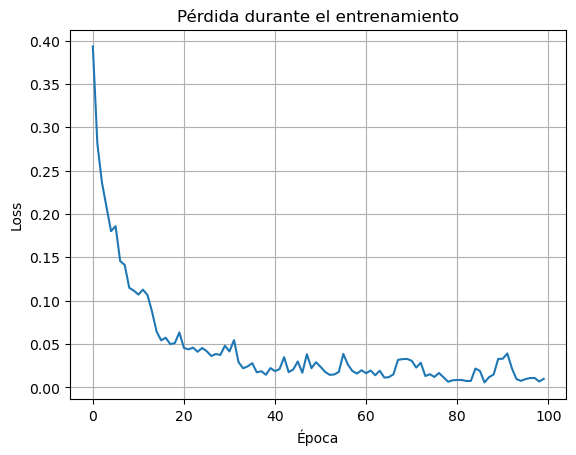

In [13]:
threshold = 0.001
epochs = 100
loss_history = []

for epoch in range(epochs):
    model.train() 
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)   
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f'Epoch {epoch + 1}, Train Loss: {epoch_loss:.4f}')

    correct, total = 0, 0
    y_true, y_pred = [], []
    model.eval() 
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1] 
            predicted = (probs >= threshold).long()

            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            y_true.extend(labels.cpu().numpy()) 
            y_pred.extend(predicted.cpu().numpy())

        accuracy = 100 * correct / total

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0 
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f'Accuracy: {accuracy:.2f}% | Sensibilidad: {sensitivity:.2f} | Especificidad: {specificity:.2f}')
    
   
    #wandb.log({
    #"train_loss": epoch_loss,
    #"test_accuracy": accuracy,  
    #"test_sensitivity": sensitivity,
    #"test_specificity": specificity,})

plt.plot(loss_history)
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

#wandb.finish()

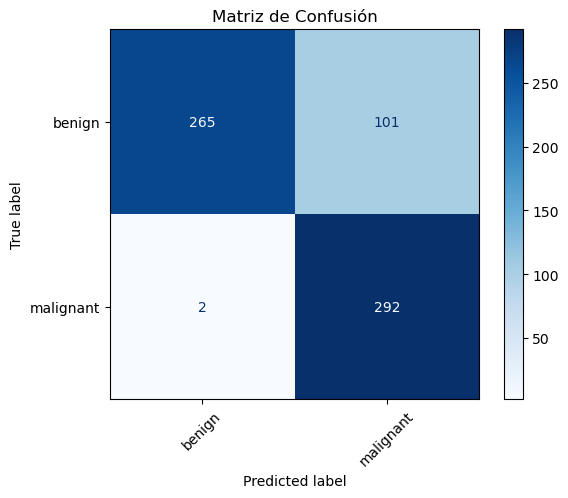

In [14]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión")
plt.show()